# 32 — Breakfast Qwen3.5-2B full-catalog alignment

This notebook is the focused follow-up requested by Federico: repeat the
catalog-constrained pseudo-text experiment on **Breakfast split 1**, where the
catalog contains 48 actions instead of Assembly101's 202.

The experiment reuses the frozen ProcedureVRL hidden representation and the
frozen privileged-text teacher trained in notebook 11. No model is retrained.
The main question is whether a smaller closed-set catalog prevents Qwen class
collapse and makes pseudo-text useful at inference.

Run once with **Runtime → Run all**. Every generated video is checkpointed to
Google Drive, and transient failures are retried automatically.

## Experimental contract

- **Dataset:** Breakfast, official split 1 test set, 252 videos.
- **Catalog:** all 48 Breakfast actions.
- **VLM:** Qwen3.5-2B, matching the Assembly101 catalog experiment.
- **Temporal representation:** 16 uniformly ordered frames and 16 teacher steps.
- **Primary candidate:** frozen teacher + direct Qwen top-1 label embedding.
- **Diagnostic candidate:** neighbor-smoothed Qwen label embedding.
- **Baselines:** controlled visual student, zero-text teacher, shuffled pseudo-text,
  and oracle ground-truth text teacher.
- **Primary metric:** F1@50; Accuracy, Edit, F1@10 and F1@25 are also reported.

Methodological limitation: the existing Breakfast checkpoints were selected on
the same official split-1 test set in notebook 11. Therefore this is an
**exploratory cross-dataset diagnostic**, not a new unbiased held-out estimate.
Ground-truth labels are not loaded until Qwen generation is complete.

## 1. Mount Google Drive

In [9]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


## 2. Install dependencies

In [10]:
# %pip install -U "transformers>=5.14.0,<6" "accelerate>=1.10,<2" "safetensors>=0.5" "huggingface_hub[hf_xet]>=0.35" decord opencv-python-headless pillow pandas tqdm matplotlib

## 3. Imports, deterministic settings, and GPU audit

In [11]:
from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import os
import platform
import random
import re
import shutil
import subprocess
import time
import traceback

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
from decord import VideoReader, cpu
from huggingface_hub import get_token, login
from tqdm.auto import tqdm
from transformers import AutoModelForMultimodalLM, AutoProcessor

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 240)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError(
        "A CUDA GPU is required. In Colab choose Runtime -> Change runtime type -> T4 GPU."
    )

GPU_NAME = torch.cuda.get_device_name(0)
GPU_TOTAL_GIB = torch.cuda.get_device_properties(0).total_memory / 1024**3
MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("GPU:", GPU_NAME)
print("GPU memory:", f"{GPU_TOTAL_GIB:.2f} GiB")
print("Qwen dtype:", MODEL_DTYPE)
subprocess.run(["nvidia-smi"], check=False)

if GPU_TOTAL_GIB < 10:
    raise RuntimeError(f"This Qwen3.5-2B protocol expects at least 10 GiB VRAM; found {GPU_TOTAL_GIB:.2f} GiB.")

Python: 3.13.15
PyTorch: 2.11.0+cu128
GPU: Tesla T4
GPU memory: 14.56 GiB
Qwen dtype: torch.bfloat16


## 4. Locked configuration and paths

In [12]:
RUN_MODE = "breakfast_split1_full_one_run"
QWEN_MODEL_ID = "Qwen/Qwen3.5-2B"
EXPERIMENT_ID = "breakfast_split1_qwen35_2b_catalog_top1_lines4_v1"
PROMPT_VERSION = "breakfast_catalog_top1_id_score_lines4_v1"
PARSER_VERSION = "expected_steps_first_occurrence_v2"

EXPECTED_NUM_CLASSES = 48
EXPECTED_TEXT_DIM = 512
EXPECTED_VIDEO_DIM = 512
EXPECTED_TEMPORAL_LENGTH = 16
EXPECTED_TEST_VIDEOS = 252
NUM_TEMPORAL_STEPS = 16
FRAMES_PER_PROMPT = 4
TOP_K = 1
FRAME_SIDE = 224
PROCESSOR_MAX_IMAGE_PIXELS = FRAME_SIDE * FRAME_SIDE
JPEG_QUALITY = 90
MAX_NEW_TOKENS = 128
MAX_GENERATION_ATTEMPTS = 3
MAX_AUTOMATIC_PASSES = 3
MAX_COPY_ATTEMPTS = 5
RETRY_SLEEP_SECONDS = 8
TEMPORAL_SELF_WEIGHT = 0.80
TEMPORAL_NEIGHBOR_WEIGHT = 0.10
FORCE_REGENERATE = False
DELETE_LOCAL_VIDEO = True
DELETE_TEMP_FRAMES = True

PRIMARY_VARIANT = "teacher_qwen_top1"
MIN_REQUIRED_F1_50_GAIN = 0.30
REPRODUCTION_TOLERANCE = 0.05

# Verified Assembly101 notebook-31 reference. Raw F1 values are not compared
# directly across datasets; collapse diagnostics are shown descriptively.
ASSEMBLY101_REFERENCE = {
    "catalog_classes": 202,
    "visual_f1@50": 18.97,
    "qwen_direct_f1@50": 2.94,
    "qwen_temporal_f1@50": 3.46,
    "oracle_f1@50": 34.14,
    "top1_accuracy_percent": 2.86,
    "unique_top1_classes": 9,
    "unique_target_classes": 154,
    "largest_top1_class_share_percent": 84.58,
}

DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
BREAKFAST_ROOT = DRIVE_ROOT / "text_assisted_tas" / "breakfast"
HIDDEN_RUN_ROOT = (
    BREAKFAST_ROOT / "procedurevrl_hidden" / "runs"
    / "procedurevrl_hidden_full_split1_split1_views16"
)
DATA_DRIVE_ROOT = HIDDEN_RUN_ROOT / "mstcn_format"
FEATURE_DRIVE_DIR = DATA_DRIVE_ROOT / "features"
GT_DRIVE_DIR = DATA_DRIVE_ROOT / "groundTruth"
SPLIT_DRIVE_DIR = DATA_DRIVE_ROOT / "splits"
MAPPING_DRIVE_PATH = DATA_DRIVE_ROOT / "mapping.txt"
TEST_BUNDLE_DRIVE = SPLIT_DRIVE_DIR / "test.split1.bundle"
VIDEO_MANIFEST_DRIVE = HIDDEN_RUN_ROOT / "hidden_used_video_manifest.csv"

TEXT_DRIVE_ROOT = BREAKFAST_ROOT / "text_embeddings"
TEXT_EMBEDDING_DRIVE = TEXT_DRIVE_ROOT / "breakfast_clip_vitb16_text_embeddings.npy"
TEXT_METADATA_DRIVE = TEXT_DRIVE_ROOT / "breakfast_clip_vitb16_text_embedding_metadata.csv"

PRIOR_RUN_ROOT = (
    BREAKFAST_ROOT / "procedurevrl_hidden" / "runs"
    / "procedurevrl_hidden_privileged_text_teacher_kd_full_split1_split1"
)
PRIOR_MODEL_DIR = PRIOR_RUN_ROOT / "models"
PRIOR_RESULTS_DIR = PRIOR_RUN_ROOT / "results"
VISUAL_CHECKPOINT_DRIVE = PRIOR_MODEL_DIR / "controlled_ce_student_best.pt"
TEACHER_CHECKPOINT_DRIVE = PRIOR_MODEL_DIR / "privileged_teacher_best.pt"
TRAIN_MEAN_DRIVE = PRIOR_RESULTS_DIR / "train_feature_mean.npy"
TRAIN_STD_DRIVE = PRIOR_RESULTS_DIR / "train_feature_std.npy"
PRIOR_SUMMARY_DRIVE = PRIOR_RESULTS_DIR / "final_summary.json"

DRIVE_OUT_ROOT = BREAKFAST_ROOT / "runs" / "32_breakfast_qwen_catalog_top1_alignment" / EXPERIMENT_ID
DRIVE_PARSED_DIR = DRIVE_OUT_ROOT / "parsed_predictions"
DRIVE_PROBABILITY_DIR = DRIVE_OUT_ROOT / "class_probabilities"
DRIVE_TOP1_DIR = DRIVE_OUT_ROOT / "top1_embeddings"
DRIVE_TEMPORAL_DIR = DRIVE_OUT_ROOT / "top1_temporal_embeddings"
DRIVE_RAW_DIR = DRIVE_OUT_ROOT / "raw_responses"
DRIVE_ARTIFACT_DIR = DRIVE_OUT_ROOT / "presentation_artifacts"

LOCAL_ROOT = Path("/content/nb32_breakfast_runtime")
LOCAL_INPUT_DIR = LOCAL_ROOT / "inputs"
LOCAL_VIDEO_DIR = LOCAL_ROOT / "videos"
LOCAL_FRAME_DIR = LOCAL_ROOT / "frames"
LOCAL_OUT_ROOT = LOCAL_ROOT / "outputs"
LOCAL_PARSED_DIR = LOCAL_OUT_ROOT / "parsed_predictions"
LOCAL_PROBABILITY_DIR = LOCAL_OUT_ROOT / "class_probabilities"
LOCAL_TOP1_DIR = LOCAL_OUT_ROOT / "top1_embeddings"
LOCAL_TEMPORAL_DIR = LOCAL_OUT_ROOT / "top1_temporal_embeddings"
LOCAL_RAW_DIR = LOCAL_OUT_ROOT / "raw_responses"
LOCAL_ARTIFACT_DIR = LOCAL_OUT_ROOT / "presentation_artifacts"
LOCAL_EVAL_DIR = LOCAL_ROOT / "evaluation"
LOCAL_FEATURE_DIR = LOCAL_EVAL_DIR / "features"
LOCAL_GT_DIR = LOCAL_EVAL_DIR / "groundTruth"

for path in [
    DRIVE_OUT_ROOT, DRIVE_PARSED_DIR, DRIVE_PROBABILITY_DIR, DRIVE_TOP1_DIR,
    DRIVE_TEMPORAL_DIR, DRIVE_RAW_DIR, DRIVE_ARTIFACT_DIR,
    LOCAL_INPUT_DIR, LOCAL_VIDEO_DIR, LOCAL_FRAME_DIR, LOCAL_OUT_ROOT,
    LOCAL_PARSED_DIR, LOCAL_PROBABILITY_DIR, LOCAL_TOP1_DIR,
    LOCAL_TEMPORAL_DIR, LOCAL_RAW_DIR, LOCAL_ARTIFACT_DIR,
    LOCAL_EVAL_DIR, LOCAL_FEATURE_DIR, LOCAL_GT_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("RUN_MODE:", RUN_MODE)
print("Experiment:", EXPERIMENT_ID)
print("Persistent output:", DRIVE_OUT_ROOT)

RUN_MODE: breakfast_split1_full_one_run
Experiment: breakfast_split1_qwen35_2b_catalog_top1_lines4_v1
Persistent output: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/breakfast/runs/32_breakfast_qwen_catalog_top1_alignment/breakfast_split1_qwen35_2b_catalog_top1_lines4_v1


## 5. Robust Google Drive I/O

In [13]:
def remount_google_drive():
    print("Google Drive connection was lost. Remounting...")
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    time.sleep(2)
    drive.mount("/content/drive", force_remount=True)


def copy_with_retry(source, destination, max_attempts=MAX_COPY_ATTEMPTS, overwrite=True):
    source = Path(source)
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".part")
    for attempt in range(1, max_attempts + 1):
        try:
            destination.parent.mkdir(parents=True, exist_ok=True)
            if not overwrite and destination.exists() and destination.stat().st_size > 0:
                return destination
            if temporary.exists():
                temporary.unlink()
            expected_size = source.stat().st_size
            shutil.copyfile(source, temporary)
            if temporary.stat().st_size != expected_size:
                raise OSError(f"Incomplete copy: {source}")
            temporary.replace(destination)
            return destination
        except OSError as error:
            try:
                if temporary.exists():
                    temporary.unlink()
            except OSError:
                pass
            if attempt == max_attempts:
                raise
            if getattr(error, "errno", None) == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)


def drive_file_available(path, max_attempts=4):
    path = Path(path)
    for attempt in range(1, max_attempts + 1):
        try:
            return path.exists() and path.stat().st_size > 0
        except OSError as error:
            if attempt == max_attempts:
                return False
            if getattr(error, "errno", None) == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)
    return False


def save_json_local(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, ensure_ascii=False), encoding="utf-8")
    temporary.replace(path)


def save_npy_local(path, value):
    path = Path(path)
    temporary = path.with_name(path.stem + ".tmp.npy")
    np.save(temporary, value)
    temporary.replace(path)


def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(encoding="utf-8", errors="replace").splitlines()
        if line.strip()
    ]


print("Robust I/O helpers ready.")

Robust I/O helpers ready.


## 6. Authenticate optionally and stage label-free generation inputs

In [14]:
try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = None

if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    print("Authenticated using HF_TOKEN.")
elif get_token() is not None:
    print("Using a cached Hugging Face token.")
else:
    print("No HF token found; Qwen3.5-2B is public, so model loading will continue anonymously.")

generation_inputs = {
    "mapping.txt": MAPPING_DRIVE_PATH,
    "test.split1.bundle": TEST_BUNDLE_DRIVE,
    "text_embeddings.npy": TEXT_EMBEDDING_DRIVE,
    "text_metadata.csv": TEXT_METADATA_DRIVE,
    "video_manifest.csv": VIDEO_MANIFEST_DRIVE,
}
for local_name, drive_path in tqdm(generation_inputs.items(), desc="Stage label-free inputs"):
    if not drive_file_available(drive_path):
        raise FileNotFoundError(f"Missing prerequisite: {drive_path}")
    copy_with_retry(drive_path, LOCAL_INPUT_DIR / local_name)


def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        parts = line.split(maxsplit=1)
        if len(parts) != 2:
            raise ValueError(f"Malformed mapping line: {line}")
        class_id = int(parts[0])
        label = parts[1].strip()
        if class_id in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[class_id] = label
        label_to_id[label] = class_id
    return id_to_label, label_to_id


ID_TO_LABEL, LABEL_TO_ID = load_mapping(LOCAL_INPUT_DIR / "mapping.txt")
if set(ID_TO_LABEL) != set(range(EXPECTED_NUM_CLASSES)):
    raise RuntimeError(f"Expected contiguous Breakfast IDs 0..47, got {sorted(ID_TO_LABEL)}")

test_ids = [Path(line).stem for line in read_nonempty_lines(LOCAL_INPUT_DIR / "test.split1.bundle")]
if len(test_ids) != EXPECTED_TEST_VIDEOS or len(test_ids) != len(set(test_ids)):
    raise RuntimeError(f"Expected {EXPECTED_TEST_VIDEOS} unique split-1 test videos, got {len(test_ids)}")

text_embeddings = np.load(LOCAL_INPUT_DIR / "text_embeddings.npy").astype(np.float32)
text_metadata = pd.read_csv(LOCAL_INPUT_DIR / "text_metadata.csv")
if text_embeddings.shape != (EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM):
    raise RuntimeError(f"Unexpected Breakfast text embeddings: {text_embeddings.shape}")

# Match notebook 11's ordering logic exactly.
label_column = None
for column in ["label", "action", "action_label", "class_name", "class_label", "name", "text"]:
    if column in text_metadata.columns:
        values = set(str(value) for value in text_metadata[column].tolist())
        if len(values.intersection(set(LABEL_TO_ID))) >= int(0.8 * EXPECTED_NUM_CLASSES):
            label_column = column
            break
if label_column is not None:
    row_by_label = {str(row[label_column]): index for index, row in text_metadata.iterrows()}
    reordered = np.zeros_like(text_embeddings)
    for class_id, label in ID_TO_LABEL.items():
        if label not in row_by_label:
            raise RuntimeError(f"Missing text embedding metadata label: {label}")
        reordered[class_id] = text_embeddings[row_by_label[label]]
    text_embeddings = reordered
else:
    print("Text metadata has no reliable label column; retaining notebook-11 mapping-ID order.")
text_embeddings /= np.maximum(np.linalg.norm(text_embeddings, axis=1, keepdims=True), 1e-12)

video_manifest = pd.read_csv(LOCAL_INPUT_DIR / "video_manifest.csv")
required_manifest_columns = {"video_id", "split", "video_path", "duration_sec"}
missing_columns = required_manifest_columns - set(video_manifest.columns)
if missing_columns:
    raise KeyError(f"Video manifest is missing columns: {sorted(missing_columns)}")
video_manifest["video_id"] = video_manifest["video_id"].astype(str)
if video_manifest["video_id"].duplicated().any():
    raise RuntimeError("Video manifest contains duplicate video IDs.")

manifest_by_id = video_manifest.set_index("video_id")
missing_videos = [video_id for video_id in test_ids if video_id not in manifest_by_id.index]
if missing_videos:
    raise RuntimeError(f"Test videos missing from raw-video manifest: {missing_videos[:10]}")

cohort = manifest_by_id.loc[test_ids].reset_index().copy()
cohort["duration_sec"] = pd.to_numeric(cohort["duration_sec"], errors="raise")
cohort["split"] = "test"
if len(cohort) != EXPECTED_TEST_VIDEOS:
    raise RuntimeError(f"Unexpected cohort size: {len(cohort)}")

print("Breakfast classes:", len(ID_TO_LABEL))
print("Split-1 test videos:", len(cohort))
print("Ground truth loaded: False")
display(pd.DataFrame({"class_id": list(ID_TO_LABEL), "label": list(ID_TO_LABEL.values())}).head(48))

Authenticated using HF_TOKEN.


Stage label-free inputs:   0%|          | 0/5 [00:00<?, ?it/s]

Breakfast classes: 48
Split-1 test videos: 252
Ground truth loaded: False


,class_id,label
0,0,SIL
1,1,pour_cereals
2,2,pour_milk
3,3,stir_cereals
4,4,take_bowl
5,5,pour_coffee
6,6,take_cup
7,7,spoon_sugar
8,8,stir_coffee
9,9,pour_sugar


## 7. Freeze the 48-class closed-set prompt

In [15]:
def humanize_label(label):
    return str(label).replace("_", " ").replace("-", " ").strip()


LABEL_CATALOG_TEXT = "\n".join(
    f"{class_id}: {humanize_label(label)}"
    for class_id, label in ID_TO_LABEL.items()
)

PROMPT_PREFIX = (
    "You are performing closed-set temporal action recognition for the Breakfast Actions dataset.\n"
    "The ordered frames show a person preparing breakfast in a kitchen. Select actions only "
    "from the complete catalog below. Use the manipulated object, hand motion, and temporal "
    "context. Output only the requested compact lines, without captions, explanations, "
    "Markdown, or JSON.\n\n"
)


def build_catalog_prompt(step_indices):
    step_indices = [int(index) for index in step_indices]
    return (
        PROMPT_PREFIX
        + f"The {len(step_indices)} images correspond in order to global temporal steps {step_indices}. "
        + "Return exactly one line for every listed step.\n"
        + f"For each step choose one label_id from 0 to {EXPECTED_NUM_CLASSES - 1}. "
        + "Add a non-negative confidence score.\n"
        + "Use exactly this format:\n"
        + "STEP <global_step> | <label_id>:<score>\n"
        + "Return only the STEP lines. Never invent an ID outside the catalog.\n\n"
        + "Complete allowed Breakfast action catalog:\n"
        + LABEL_CATALOG_TEXT
    )


PROMPT_CONTRACT = (
    PROMPT_PREFIX + LABEL_CATALOG_TEXT
    + f"|top_k={TOP_K}|frames_per_prompt={FRAMES_PER_PROMPT}|version={PROMPT_VERSION}"
)
PROMPT_HASH = hashlib.sha256(PROMPT_CONTRACT.encode("utf-8")).hexdigest()

frozen_config = {
    "experiment_id": EXPERIMENT_ID,
    "dataset": "Breakfast",
    "official_split": 1,
    "evaluation_subset": "test",
    "model_id": QWEN_MODEL_ID,
    "prompt_version": PROMPT_VERSION,
    "parser_version": PARSER_VERSION,
    "prompt_sha256": PROMPT_HASH,
    "catalog_size": EXPECTED_NUM_CLASSES,
    "top_k": TOP_K,
    "frames_per_prompt": FRAMES_PER_PROMPT,
    "num_temporal_steps": NUM_TEMPORAL_STEPS,
    "generation": {"do_sample": False, "max_new_tokens": MAX_NEW_TOKENS},
    "primary_variant": PRIMARY_VARIANT,
    "ground_truth_available_during_generation": False,
    "exploratory_test_evaluation": True,
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
save_json_local(LOCAL_OUT_ROOT / "frozen_config.json", frozen_config)
copy_with_retry(LOCAL_OUT_ROOT / "frozen_config.json", DRIVE_OUT_ROOT / "frozen_config.json")

print("Prompt SHA256:", PROMPT_HASH)
print("Catalog size:", EXPECTED_NUM_CLASSES)
print("Prompt characters:", len(build_catalog_prompt(range(FRAMES_PER_PROMPT))))

Prompt SHA256: b7c18272a20b9d3717ef18f2d28d28e64e6cb5063976baf2a65c55aeb83252c8
Catalog size: 48
Prompt characters: 1492


## 8. Resumable output validation and cohort status

In [16]:
def sequence_output_paths(root, video_id):
    root = Path(root)
    return {
        "metadata": root / "parsed_predictions" / f"{video_id}.json",
        "probabilities": root / "class_probabilities" / f"{video_id}.npy",
        "top1": root / "top1_embeddings" / f"{video_id}.npy",
        "temporal": root / "top1_temporal_embeddings" / f"{video_id}.npy",
    }


def saved_output_is_valid(video_id, refresh_local=False):
    drive_paths = sequence_output_paths(DRIVE_OUT_ROOT, video_id)
    local_paths = sequence_output_paths(LOCAL_OUT_ROOT, video_id)
    if not all(drive_file_available(path) for path in drive_paths.values()):
        return False
    try:
        for key in drive_paths:
            if refresh_local or not local_paths[key].exists():
                copy_with_retry(drive_paths[key], local_paths[key])
        metadata = json.loads(local_paths["metadata"].read_text(encoding="utf-8"))
        probabilities = np.load(local_paths["probabilities"])
        top1 = np.load(local_paths["top1"])
        temporal = np.load(local_paths["temporal"])
        return bool(
            metadata.get("prompt_sha256") == PROMPT_HASH
            and metadata.get("model_id") == QWEN_MODEL_ID
            and metadata.get("ground_truth_used") is False
            and probabilities.shape == (NUM_TEMPORAL_STEPS, EXPECTED_NUM_CLASSES)
            and top1.shape == (EXPECTED_TEXT_DIM, NUM_TEMPORAL_STEPS)
            and temporal.shape == (EXPECTED_TEXT_DIM, NUM_TEMPORAL_STEPS)
            and np.isfinite(probabilities).all()
            and np.isfinite(top1).all()
            and np.isfinite(temporal).all()
            and np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5)
        )
    except Exception:
        return False


cohort["complete_before_run"] = cohort["video_id"].map(saved_output_is_valid)
pending_at_start = cohort[~cohort["complete_before_run"]].copy()
print("Fixed cohort:", len(cohort))
print("Already complete:", int(cohort["complete_before_run"].sum()))
print("Pending:", len(pending_at_start))

Fixed cohort: 252
Already complete: 243
Pending: 9


## 9. Load Qwen3.5-2B only if generation work remains

In [17]:
torch.cuda.empty_cache()
gc.collect()

if pending_at_start.empty:
    processor = None
    model = None
    MODEL_DEVICE = torch.device("cuda")
    print("All Breakfast videos are already complete; Qwen loading skipped.")
else:
    processor = AutoProcessor.from_pretrained(
        QWEN_MODEL_ID,
        max_image_size={"longest_edge": PROCESSOR_MAX_IMAGE_PIXELS},
    )
    processor.tokenizer.padding_side = "left"
    model = AutoModelForMultimodalLM.from_pretrained(
        QWEN_MODEL_ID,
        dtype=MODEL_DTYPE,
        device_map={"": 0},
        low_cpu_mem_usage=True,
        attn_implementation="sdpa",
    )
    model.eval()
    MODEL_DEVICE = next(model.parameters()).device
    if MODEL_DEVICE.type != "cuda":
        raise RuntimeError(f"Qwen was not placed on CUDA: {MODEL_DEVICE}")
    print("Model device:", MODEL_DEVICE)
    print("Parameters:", f"{sum(parameter.numel() for parameter in model.parameters()) / 1e9:.3f} B")
    print("Model footprint:", f"{model.get_memory_footprint() / 1024**3:.2f} GiB")

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/64.5k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…): reconstructing file:   0%|          |  0.00B / 4.55GB            

model.safetensors-00001-of-00001.safeten(…): downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

Model device: cuda:0
Parameters: 2.213 B
Model footprint: 4.12 GiB


## 10. Deterministic 16-frame sampling with decoder fallback

In [18]:
CENTER_POSITIONS = (np.arange(NUM_TEMPORAL_STEPS, dtype=np.float64) + 0.5) / NUM_TEMPORAL_STEPS


def letterbox_frame(frame, side=FRAME_SIDE):
    image = Image.fromarray(frame).convert("RGB")
    image = ImageOps.contain(image, (side, side), Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (side, side), color=(0, 0, 0))
    offset = ((side - image.width) // 2, (side - image.height) // 2)
    canvas.paste(image, offset)
    return canvas


def sample_frames_decord(video_path):
    reader = VideoReader(str(video_path), ctx=cpu(0))
    total_frames = len(reader)
    if total_frames <= 0:
        raise RuntimeError("Decord reported zero frames.")
    indices = np.rint(CENTER_POSITIONS * (total_frames - 1)).astype(np.int64)
    indices = np.clip(indices, 0, total_frames - 1)
    frames = reader.get_batch(indices.tolist()).asnumpy()
    return frames, indices, "decord"


def sample_frames_opencv(video_path):
    capture = cv2.VideoCapture(str(video_path))
    total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        capture.release()
        raise RuntimeError("OpenCV reported zero frames.")
    indices = np.rint(CENTER_POSITIONS * (total_frames - 1)).astype(np.int64)
    frames = []
    for index in indices:
        capture.set(cv2.CAP_PROP_POS_FRAMES, int(index))
        ok, frame_bgr = capture.read()
        if not ok:
            capture.release()
            raise RuntimeError(f"OpenCV failed at frame {index}.")
        frames.append(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    capture.release()
    return np.stack(frames), indices, "opencv"


def sample_video_frames(video_path):
    try:
        return sample_frames_decord(video_path)
    except Exception as decord_error:
        print(f"Decord failed ({type(decord_error).__name__}); retrying with OpenCV.")
        return sample_frames_opencv(video_path)


def save_temporary_frames(video_id, frames):
    video_dir = LOCAL_FRAME_DIR / str(video_id)
    if video_dir.exists():
        shutil.rmtree(video_dir)
    video_dir.mkdir(parents=True, exist_ok=True)
    frame_paths = []
    for step_index, frame in enumerate(frames):
        frame_path = video_dir / f"frame_{step_index:02d}.jpg"
        letterbox_frame(frame).save(frame_path, format="JPEG", quality=JPEG_QUALITY, optimize=True)
        frame_paths.append(frame_path)
    return video_dir, frame_paths


print("Temporal centers:", CENTER_POSITIONS.tolist())

Temporal centers: [0.03125, 0.09375, 0.15625, 0.21875, 0.28125, 0.34375, 0.40625, 0.46875, 0.53125, 0.59375, 0.65625, 0.71875, 0.78125, 0.84375, 0.90625, 0.96875]


## 11. Tolerant closed-set response parser

In [19]:
def parse_compact_lines(raw_text):
    rows = []
    line_pattern = re.compile(r"^\s*STEP\s+(\d+)\s*\|\s*(.+?)\s*$", re.IGNORECASE)
    candidate_pattern = re.compile(r"^\s*(\d+)\s*(?::\s*(.*?))?\s*$")
    for line in raw_text.replace(chr(96) * 3, "").splitlines():
        match = line_pattern.match(line)
        if not match:
            continue
        token = match.group(2).split(",")[0]
        candidate_match = candidate_pattern.match(token)
        if not candidate_match:
            # Ignore malformed continuations. The closed-set validator below
            # still requires one valid candidate for every requested step.
            continue
        label_id = int(candidate_match.group(1))
        score_text = candidate_match.group(2)
        try:
            score = float(score_text)
            if not np.isfinite(score) or score < 0:
                raise ValueError
            score_source = "model_score"
        except Exception:
            score = 1.0
            score_source = "rank_fallback"
        rows.append({
            "step": int(match.group(1)),
            "label_id": label_id,
            "score": score,
            "score_source": score_source,
        })
    return rows


def parse_closed_set_response(raw_text, expected_steps):
    expected_steps = [int(step) for step in expected_steps]
    rows = parse_compact_lines(raw_text)
    if not rows:
        raise ValueError("No valid STEP lines were found.")
    observed_steps = [row["step"] for row in rows]
    first_requested_row = {}
    expected_step_set = set(expected_steps)
    for row in rows:
        step = int(row["step"])
        if step in expected_step_set and step not in first_requested_row:
            first_requested_row[step] = row

    if all(step in first_requested_row for step in expected_steps):
        rows = [first_requested_row[step] for step in expected_steps]
        step_source = "model" if observed_steps == expected_steps else "model_trimmed"
    elif len(rows) == len(expected_steps) and len(set(observed_steps)) == len(rows):
        for row, expected_step in zip(rows, expected_steps):
            row["step"] = expected_step
        step_source = "positional_repair"
    else:
        raise ValueError(f"Expected steps {expected_steps}, got {observed_steps}")

    parsed = {}
    for row in rows:
        step = int(row["step"])
        label_id = int(row["label_id"])
        if step in parsed:
            raise ValueError(f"Duplicate step {step}")
        if not 0 <= label_id < EXPECTED_NUM_CLASSES:
            raise ValueError(f"Out-of-catalog label ID {label_id}")
        parsed[step] = {
            "step": step,
            "candidate_ids": [label_id],
            "candidate_labels": [ID_TO_LABEL[label_id]],
            "candidate_scores": [1.0],
            "score_source": row["score_source"],
            "step_index_source": step_source,
        }
    if sorted(parsed) != sorted(expected_steps):
        raise ValueError(f"Missing expected steps: {expected_steps}; got {sorted(parsed)}")
    return [parsed[step] for step in expected_steps]


print("Closed-set parser ready.")

Closed-set parser ready.


## 12. Qwen generation functions

In [20]:
def build_messages(frame_paths, prompt, media_mode):
    if media_mode == "ordered_images":
        visual_content = [{"type": "image", "path": str(path)} for path in frame_paths]
    elif media_mode == "video_frame_list":
        visual_content = [{"type": "video", "path": [str(path) for path in frame_paths]}]
    else:
        raise ValueError(f"Unknown media mode: {media_mode}")
    return [{"role": "user", "content": visual_content + [{"type": "text", "text": prompt}]}]


def prepare_multimodal_inputs(frame_paths, prompt):
    errors = []
    for media_mode in ["ordered_images", "video_frame_list"]:
        try:
            messages = build_messages(frame_paths, prompt, media_mode)
            inputs = processor.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=True,
                return_dict=True,
                return_tensors="pt",
                enable_thinking=False,
            )
            return inputs.to(MODEL_DEVICE), media_mode
        except Exception as error:
            errors.append(f"{media_mode}: {type(error).__name__}: {error}")
    raise RuntimeError("Both multimodal input modes failed:\n" + "\n".join(errors))


def generate_once(frame_paths, prompt, use_cache=True):
    inputs = None
    generated_ids = None
    continuation = None
    try:
        inputs, media_mode = prepare_multimodal_inputs(frame_paths, prompt)
        input_tokens = int(inputs["input_ids"].shape[-1])
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        started = time.perf_counter()
        with torch.inference_mode():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                use_cache=use_cache,
                pad_token_id=processor.tokenizer.eos_token_id,
            )
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - started
        continuation = generated_ids[:, input_tokens:]
        raw_text = processor.batch_decode(
            continuation,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0].strip()
        return {
            "raw_text": raw_text,
            "media_mode": media_mode,
            "input_tokens": input_tokens,
            "output_tokens": int(continuation.shape[-1]),
            "generation_seconds": float(elapsed),
            "peak_gpu_gib": float(torch.cuda.max_memory_allocated() / 1024**3),
            "use_cache": bool(use_cache),
        }
    finally:
        del inputs, generated_ids, continuation
        gc.collect()
        torch.cuda.empty_cache()


def generate_with_memory_fallback(frame_paths, prompt):
    try:
        return generate_once(frame_paths, prompt, use_cache=True)
    except torch.cuda.OutOfMemoryError:
        print("CUDA cache OOM: retrying the same block with use_cache=False.")
        gc.collect()
        torch.cuda.empty_cache()
        return generate_once(frame_paths, prompt, use_cache=False)


def generate_block(video_id, frame_paths, step_indices, block_index):
    validation_error = ""
    for attempt in range(1, MAX_GENERATION_ATTEMPTS + 1):
        prompt = build_catalog_prompt(step_indices)
        if attempt > 1:
            prompt += (
                "\n\nThe previous output failed validation because: "
                + validation_error[:400]
                + "\nReturn corrected STEP lines only."
            )
        generation = generate_with_memory_fallback(frame_paths, prompt)
        raw_path = LOCAL_RAW_DIR / f"{video_id}.block_{block_index}.attempt_{attempt}.txt"
        raw_path.write_text(generation["raw_text"], encoding="utf-8")
        copy_with_retry(raw_path, DRIVE_RAW_DIR / raw_path.name)
        try:
            steps = parse_closed_set_response(generation["raw_text"], step_indices)
            return {"steps": steps, "attempt": attempt, "raw_path": str(raw_path), **generation}
        except Exception as error:
            validation_error = f"{type(error).__name__}: {error}"
            preview = generation["raw_text"][:500].replace("\n", "\\n")
            print(f"{video_id} block {block_index} attempt {attempt}: {validation_error}; {preview!r}")
    raise RuntimeError(f"No valid response for {video_id} block {block_index}: {validation_error}")


print("Qwen generation functions ready.")

Qwen generation functions ready.


## 13. Generate and checkpoint all 252 Breakfast videos

In [21]:
def l2_normalize_columns(array):
    return array / np.maximum(np.linalg.norm(array, axis=0, keepdims=True), 1e-12)


def build_sequence_artifacts(steps):
    steps = sorted(steps, key=lambda row: int(row["step"]))
    if [int(row["step"]) for row in steps] != list(range(NUM_TEMPORAL_STEPS)):
        raise ValueError("Combined steps are not exactly 0..15.")
    probabilities = np.zeros((NUM_TEMPORAL_STEPS, EXPECTED_NUM_CLASSES), dtype=np.float32)
    for row in steps:
        probabilities[int(row["step"]), int(row["candidate_ids"][0])] = 1.0
    top1_ids = probabilities.argmax(axis=1)
    top1_embedding = text_embeddings[top1_ids].T.astype(np.float32)

    temporal_probabilities = TEMPORAL_SELF_WEIGHT * probabilities
    temporal_probabilities[1:] += TEMPORAL_NEIGHBOR_WEIGHT * probabilities[:-1]
    temporal_probabilities[:-1] += TEMPORAL_NEIGHBOR_WEIGHT * probabilities[1:]
    temporal_probabilities /= np.maximum(temporal_probabilities.sum(axis=1, keepdims=True), 1e-12)
    temporal_embedding = (temporal_probabilities @ text_embeddings).T.astype(np.float32)
    temporal_embedding = l2_normalize_columns(temporal_embedding).astype(np.float32)
    return probabilities, top1_embedding, temporal_embedding


def persist_video_result(video_id, metadata, arrays):
    local_paths = sequence_output_paths(LOCAL_OUT_ROOT, video_id)
    drive_paths = sequence_output_paths(DRIVE_OUT_ROOT, video_id)
    probabilities, top1, temporal = arrays
    save_npy_local(local_paths["probabilities"], probabilities)
    save_npy_local(local_paths["top1"], top1)
    save_npy_local(local_paths["temporal"], temporal)
    save_json_local(local_paths["metadata"], metadata)
    for key in local_paths:
        copy_with_retry(local_paths[key], drive_paths[key])


def copy_video_locally(row):
    source = Path(str(row.video_path))
    if not drive_file_available(source):
        raise FileNotFoundError(f"Raw Breakfast video is unavailable: {source}")
    suffix = source.suffix if source.suffix else ".video"
    destination = LOCAL_VIDEO_DIR / f"{row.video_id}{suffix}"
    return copy_with_retry(source, destination)


def currently_pending():
    complete_mask = cohort["video_id"].map(saved_output_is_valid)
    return cohort[~complete_mask].copy()


session_rows = []
for automatic_pass in range(1, MAX_AUTOMATIC_PASSES + 1):
    pending = currently_pending()
    if pending.empty:
        print("All Breakfast videos are complete.")
        break
    pending = pending.sort_values(["duration_sec", "video_id"]).reset_index(drop=True)
    print(f"Automatic pass {automatic_pass}/{MAX_AUTOMATIC_PASSES}: {len(pending)} videos")

    for row in tqdm(pending.itertuples(index=False), total=len(pending), desc=f"Breakfast pass {automatic_pass}"):
        video_id = str(row.video_id)
        if not FORCE_REGENERATE and saved_output_is_valid(video_id):
            continue
        local_video = None
        frame_dir = None
        try:
            local_video = copy_video_locally(row)
            frames, frame_indices, decoder = sample_video_frames(local_video)
            frame_dir, frame_paths = save_temporary_frames(video_id, frames)

            all_steps = []
            block_records = []
            for block_index, start in enumerate(range(0, NUM_TEMPORAL_STEPS, FRAMES_PER_PROMPT)):
                stop = min(start + FRAMES_PER_PROMPT, NUM_TEMPORAL_STEPS)
                step_indices = list(range(start, stop))
                generation = generate_block(
                    video_id,
                    frame_paths[start:stop],
                    step_indices,
                    block_index,
                )
                all_steps.extend(generation["steps"])
                block_records.append({
                    "block_index": block_index,
                    "steps": step_indices,
                    "attempt": generation["attempt"],
                    "media_mode": generation["media_mode"],
                    "input_tokens": generation["input_tokens"],
                    "output_tokens": generation["output_tokens"],
                    "generation_seconds": generation["generation_seconds"],
                    "peak_gpu_gib": generation["peak_gpu_gib"],
                    "use_cache": generation["use_cache"],
                    "raw_path": generation["raw_path"],
                })

            arrays = build_sequence_artifacts(all_steps)
            metadata = {
                "video_id": video_id,
                "dataset": "Breakfast",
                "official_split": 1,
                "subset": "test",
                "model_id": QWEN_MODEL_ID,
                "experiment_id": EXPERIMENT_ID,
                "prompt_version": PROMPT_VERSION,
                "parser_version": PARSER_VERSION,
                "prompt_sha256": PROMPT_HASH,
                "catalog_size": EXPECTED_NUM_CLASSES,
                "top_k": TOP_K,
                "frames_per_prompt": FRAMES_PER_PROMPT,
                "frame_side": FRAME_SIDE,
                "decoder": decoder,
                "frame_indices": frame_indices.astype(int).tolist(),
                "duration_sec_manifest": float(row.duration_sec),
                "automatic_pass": automatic_pass,
                "blocks": block_records,
                "steps": sorted(all_steps, key=lambda value: int(value["step"])),
                "ground_truth_used": False,
                "completed_utc": datetime.now(timezone.utc).isoformat(),
            }
            persist_video_result(video_id, metadata, arrays)
            session_rows.append({
                "automatic_pass": automatic_pass,
                "video_id": video_id,
                "status": "completed",
                "generation_seconds": sum(block["generation_seconds"] for block in block_records),
                "error": "",
            })
        except Exception as error:
            session_rows.append({
                "automatic_pass": automatic_pass,
                "video_id": video_id,
                "status": "failed",
                "generation_seconds": np.nan,
                "error": f"{type(error).__name__}: {error}",
            })
            print(f"{video_id}: failed and will be retried automatically: {type(error).__name__}: {error}")
            traceback.print_exc()
        finally:
            if DELETE_TEMP_FRAMES and frame_dir is not None and frame_dir.exists():
                shutil.rmtree(frame_dir)
            if DELETE_LOCAL_VIDEO and local_video is not None and Path(local_video).exists():
                Path(local_video).unlink()
            gc.collect()
            torch.cuda.empty_cache()

    remaining = len(currently_pending())
    print(f"Remaining after pass {automatic_pass}: {remaining}")
    if remaining == 0:
        break
    time.sleep(RETRY_SLEEP_SECONDS)

session_df = pd.DataFrame(
    session_rows,
    columns=["automatic_pass", "video_id", "status", "generation_seconds", "error"],
)
session_path = LOCAL_OUT_ROOT / f"session_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}.csv"
session_df.to_csv(session_path, index=False)
copy_with_retry(session_path, DRIVE_OUT_ROOT / session_path.name)
display(session_df)

Automatic pass 1/3: 9 videos


Breakfast pass 1:   0%|          | 0/9 [00:00<?, ?it/s]

Remaining after pass 1: 0


,automatic_pass,video_id,status,generation_seconds,error
0,1,P04_webcam02_P04_tea,completed,60.500621,
1,1,P08_cam01_P08_juice,completed,58.389061,
2,1,P11_webcam01_P11_scrambledegg,completed,56.875976,
3,1,P14_stereo01_P14_scrambledegg,completed,61.836676,
4,1,P05_cam01_P05_salat,completed,59.310921,
5,1,P03_cam01_P03_friedegg,completed,63.750506,
6,1,P09_webcam01_P09_pancake,completed,58.945721,
7,1,P04_webcam02_P04_pancake,completed,59.307516,
8,1,P15_webcam01_P15_pancake,completed,58.459283,


## 14. Verify label-free generation completion

In [22]:
status_rows = []
step_rows = []
for row in cohort.itertuples(index=False):
    video_id = str(row.video_id)
    complete = saved_output_is_valid(video_id, refresh_local=True)
    status_rows.append({"video_id": video_id, "complete": bool(complete)})
    if complete:
        metadata = json.loads((LOCAL_PARSED_DIR / f"{video_id}.json").read_text(encoding="utf-8"))
        for step in metadata["steps"]:
            step_rows.append({"video_id": video_id, **step})

status_df = pd.DataFrame(status_rows)
step_df = pd.DataFrame(step_rows)
completed = int(status_df["complete"].sum())
generation_summary = {
    "status": "completed" if completed == len(cohort) else "partial",
    "run_mode": RUN_MODE,
    "dataset": "Breakfast",
    "official_split": 1,
    "subset": "test",
    "cohort_videos": int(len(cohort)),
    "completed_videos": completed,
    "remaining_videos": int(len(cohort) - completed),
    "catalog_size": EXPECTED_NUM_CLASSES,
    "model_id": QWEN_MODEL_ID,
    "prompt_sha256": PROMPT_HASH,
    "ground_truth_loaded": False,
    "updated_utc": datetime.now(timezone.utc).isoformat(),
}
status_df.to_csv(LOCAL_OUT_ROOT / "video_status.csv", index=False)
step_df.to_json(LOCAL_OUT_ROOT / "step_predictions.jsonl", orient="records", lines=True)
save_json_local(LOCAL_OUT_ROOT / "generation_summary.json", generation_summary)
for local_path in [
    LOCAL_OUT_ROOT / "video_status.csv",
    LOCAL_OUT_ROOT / "step_predictions.jsonl",
    LOCAL_OUT_ROOT / "generation_summary.json",
]:
    copy_with_retry(local_path, DRIVE_OUT_ROOT / local_path.name)

print(json.dumps(generation_summary, indent=2))
if completed != len(cohort):
    raise RuntimeError(
        f"Automatic retries were exhausted: {completed}/{len(cohort)} videos completed. "
        "Inspect the saved session CSV for the persistent error."
    )

candidate_ids = [int(row["candidate_ids"][0]) for row in step_rows]
candidate_counts = pd.Series(candidate_ids, dtype="int64").value_counts()
label_free_summary = {
    "positions": len(candidate_ids),
    "unique_predicted_classes": int(candidate_counts.size),
    "largest_class_id": int(candidate_counts.index[0]),
    "largest_class_label": ID_TO_LABEL[int(candidate_counts.index[0])],
    "largest_class_share_percent": float(100.0 * candidate_counts.iloc[0] / len(candidate_ids)),
    "ground_truth_loaded": False,
}
save_json_local(LOCAL_OUT_ROOT / "label_free_generation_summary.json", label_free_summary)
copy_with_retry(
    LOCAL_OUT_ROOT / "label_free_generation_summary.json",
    DRIVE_OUT_ROOT / "label_free_generation_summary.json",
)
print(json.dumps(label_free_summary, indent=2))
display(candidate_counts.rename("positions").head(48))

{
  "status": "completed",
  "run_mode": "breakfast_split1_full_one_run",
  "dataset": "Breakfast",
  "official_split": 1,
  "subset": "test",
  "cohort_videos": 252,
  "completed_videos": 252,
  "remaining_videos": 0,
  "catalog_size": 48,
  "model_id": "Qwen/Qwen3.5-2B",
  "prompt_sha256": "b7c18272a20b9d3717ef18f2d28d28e64e6cb5063976baf2a65c55aeb83252c8",
  "ground_truth_loaded": false,
  "updated_utc": "2026-08-26T21:42:23.574574+00:00"
}
{
  "positions": 4032,
  "unique_predicted_classes": 37,
  "largest_class_id": 1,
  "largest_class_label": "pour_cereals",
  "largest_class_share_percent": 20.1140873015873,
  "ground_truth_loaded": false
}


1     811
16    598
42    427
11    310
43    254
12    189
46    187
2     166
3     154
14    147
4     138
13    135
10    115
47    112
15     96
45     50
44     18
41     18
37     17
5      14
39     13
21     13
25      8
6       6
38      5
35      5
8       4
36      4
26      4
7       3
30      3
19      2
20      2
40      1
33      1
27      1
22      1
Name: positions, dtype: int64

## 15. Release Qwen, then stage evaluation inputs

In [23]:
if model is not None:
    del model
if processor is not None:
    del processor
gc.collect()
torch.cuda.empty_cache()
print("GPU allocated after Qwen release:", f"{torch.cuda.memory_allocated() / 1024**3:.2f} GiB")

small_evaluation_inputs = {
    "visual_checkpoint.pt": VISUAL_CHECKPOINT_DRIVE,
    "teacher_checkpoint.pt": TEACHER_CHECKPOINT_DRIVE,
    "train_mean.npy": TRAIN_MEAN_DRIVE,
    "train_std.npy": TRAIN_STD_DRIVE,
    "prior_summary.json": PRIOR_SUMMARY_DRIVE,
}
for local_name, drive_path in tqdm(small_evaluation_inputs.items(), desc="Stage evaluation metadata"):
    if not drive_file_available(drive_path):
        raise FileNotFoundError(f"Missing evaluation prerequisite: {drive_path}")
    copy_with_retry(drive_path, LOCAL_EVAL_DIR / local_name)

for video_id in tqdm(test_ids, desc="Stage Breakfast features and labels"):
    copy_with_retry(FEATURE_DRIVE_DIR / f"{video_id}.npy", LOCAL_FEATURE_DIR / f"{video_id}.npy")
    copy_with_retry(GT_DRIVE_DIR / f"{video_id}.txt", LOCAL_GT_DIR / f"{video_id}.txt")
    for key, drive_path in sequence_output_paths(DRIVE_OUT_ROOT, video_id).items():
        copy_with_retry(drive_path, sequence_output_paths(LOCAL_OUT_ROOT, video_id)[key])

print("Staged evaluation videos:", len(test_ids))
print("Ground truth loaded: True")

GPU allocated after Qwen release: 0.01 GiB


Stage evaluation metadata:   0%|          | 0/5 [00:00<?, ?it/s]

Stage Breakfast features and labels:   0%|          | 0/252 [00:00<?, ?it/s]

Staged evaluation videos: 252
Ground truth loaded: True


## 16. Frozen Breakfast model definitions and exact TAS metrics

In [24]:
DEVICE = torch.device("cuda")
INPUT_DIM = 512
TEXT_DIM = 512
NUM_STAGES = 4
NUM_LAYERS = 10
NUM_F_MAPS = 64
DROPOUT = 0.5
BATCH_SIZE = 64
NUM_WORKERS = 0

train_mean = np.load(LOCAL_EVAL_DIR / "train_mean.npy").astype(np.float32)
train_std = np.load(LOCAL_EVAL_DIR / "train_std.npy").astype(np.float32)
if train_mean.shape != (INPUT_DIM,) or train_std.shape != (INPUT_DIM,):
    raise RuntimeError(f"Unexpected normalization shapes: {train_mean.shape}, {train_std.shape}")


class DilatedResidualLayer(nn.Module):
    def __init__(self, dilation, channels, dropout):
        super().__init__()
        self.conv_dilated = nn.Conv1d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.conv_1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        output = F.relu(self.conv_dilated(inputs))
        output = self.conv_1x1(output)
        output = self.dropout(output)
        return inputs + output


class SingleStageModel(nn.Module):
    def __init__(self, num_layers, num_f_maps, input_dim, num_classes, dropout):
        super().__init__()
        self.conv_in = nn.Conv1d(input_dim, num_f_maps, kernel_size=1)
        self.layers = nn.ModuleList([
            DilatedResidualLayer(2 ** index, num_f_maps, dropout)
            for index in range(num_layers)
        ])
        self.conv_out = nn.Conv1d(num_f_maps, num_classes, kernel_size=1)

    def forward(self, inputs):
        output = self.conv_in(inputs)
        for layer in self.layers:
            output = layer(output)
        return self.conv_out(output)


class MultiStageModel(nn.Module):
    def __init__(self, num_stages, num_layers, num_f_maps, input_dim, num_classes, dropout):
        super().__init__()
        self.stage1 = SingleStageModel(num_layers, num_f_maps, input_dim, num_classes, dropout)
        self.stages = nn.ModuleList([
            SingleStageModel(num_layers, num_f_maps, num_classes, num_classes, dropout)
            for _ in range(num_stages - 1)
        ])

    def forward(self, inputs):
        outputs = []
        output = self.stage1(inputs)
        outputs.append(output)
        for stage in self.stages:
            output = stage(F.softmax(output, dim=1))
            outputs.append(output)
        return torch.stack(outputs, dim=0)


class PrivilegedTextTeacher(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = MultiStageModel(
            NUM_STAGES, NUM_LAYERS, NUM_F_MAPS,
            INPUT_DIM + TEXT_DIM, EXPECTED_NUM_CLASSES, DROPOUT,
        )

    def forward(self, video, text):
        return self.model(torch.cat([video, text], dim=1))


def collapse_segments(frame_labels, bg_classes=None):
    bg_classes = set(bg_classes or [])
    labels, starts, ends = [], [], []
    last = None
    for index, label in enumerate(frame_labels):
        if label in bg_classes:
            if last is not None:
                ends.append(index)
                last = None
            continue
        if label != last:
            if last is not None:
                ends.append(index)
            labels.append(label)
            starts.append(index)
            last = label
    if last is not None:
        ends.append(len(frame_labels))
    return labels, starts, ends


def levenshtein_distance(prediction, target):
    rows, columns = len(prediction), len(target)
    table = np.zeros((rows + 1, columns + 1), dtype=np.int32)
    table[:, 0] = np.arange(rows + 1)
    table[0, :] = np.arange(columns + 1)
    for row in range(1, rows + 1):
        for column in range(1, columns + 1):
            cost = 0 if prediction[row - 1] == target[column - 1] else 1
            table[row, column] = min(
                table[row - 1, column] + 1,
                table[row, column - 1] + 1,
                table[row - 1, column - 1] + cost,
            )
    return int(table[rows, columns])


def edit_score_single(prediction, target, bg_classes=None):
    prediction_segments, _, _ = collapse_segments(prediction, bg_classes)
    target_segments, _, _ = collapse_segments(target, bg_classes)
    if len(prediction_segments) == 0 and len(target_segments) == 0:
        return 100.0
    denominator = max(len(prediction_segments), len(target_segments))
    if denominator == 0:
        return 0.0
    return 100.0 * (1.0 - levenshtein_distance(prediction_segments, target_segments) / denominator)


def f_score_single(prediction, target, overlap, bg_classes=None):
    p_label, p_start, p_end = collapse_segments(prediction, bg_classes)
    y_label, y_start, y_end = collapse_segments(target, bg_classes)
    true_positive, false_positive = 0, 0
    hits = np.zeros(len(y_label), dtype=np.float32)
    for p_index in range(len(p_label)):
        best_iou, best_index = 0.0, -1
        for y_index in range(len(y_label)):
            if p_label[p_index] != y_label[y_index]:
                continue
            intersection = min(p_end[p_index], y_end[y_index]) - max(p_start[p_index], y_start[y_index])
            union = max(p_end[p_index], y_end[y_index]) - min(p_start[p_index], y_start[y_index])
            iou = max(intersection, 0) / union if union > 0 else 0.0
            if iou > best_iou:
                best_iou, best_index = iou, y_index
        if best_iou >= overlap and best_index >= 0 and hits[best_index] == 0:
            true_positive += 1
            hits[best_index] = 1
        else:
            false_positive += 1
    false_negative = len(y_label) - int(hits.sum())
    return true_positive, false_positive, false_negative


def compute_metrics(predictions, targets):
    background = [label for label in LABEL_TO_ID if label.lower() in {"background", "sil", "silence"}]
    total_correct, total_positions = 0, 0
    edits = []
    fstats = {0.10: [0, 0, 0], 0.25: [0, 0, 0], 0.50: [0, 0, 0]}
    for video_id, prediction in predictions.items():
        target = targets[video_id]
        if len(prediction) != len(target):
            raise RuntimeError(f"Length mismatch for {video_id}")
        total_correct += int((prediction == target).sum())
        total_positions += len(target)
        prediction_labels = [ID_TO_LABEL[int(value)] for value in prediction]
        target_labels = [ID_TO_LABEL[int(value)] for value in target]
        edits.append(edit_score_single(prediction_labels, target_labels, background))
        for overlap in fstats:
            tp, fp, fn = f_score_single(prediction_labels, target_labels, overlap, background)
            fstats[overlap][0] += tp
            fstats[overlap][1] += fp
            fstats[overlap][2] += fn
    result = {
        "acc": 100.0 * total_correct / max(total_positions, 1),
        "edit": float(np.mean(edits)),
    }
    for overlap, (tp, fp, fn) in fstats.items():
        precision = tp / max(tp + fp, 1e-10)
        recall = tp / max(tp + fn, 1e-10)
        result[f"f1@{int(100 * overlap)}"] = 100.0 * (2 * precision * recall / max(precision + recall, 1e-10))
    return result


def rounded_metrics(metrics):
    return {name: round(float(value), 2) for name, value in metrics.items()}


print("Frozen model and metric definitions ready.")

Frozen model and metric definitions ready.


## 17. Dataset, checkpoints, and reproduction checks

In [25]:
def deterministic_permutation(video_id, length):
    digest = hashlib.sha256(f"{SEED}:{video_id}:breakfast_qwen_shuffle".encode("utf-8")).digest()
    shuffle_seed = int.from_bytes(digest[:8], byteorder="little", signed=False)
    permutation = np.random.default_rng(shuffle_seed).permutation(length)
    if np.array_equal(permutation, np.arange(length)):
        permutation = np.roll(permutation, 1)
    return permutation


class BreakfastEvaluationDataset(Dataset):
    def __init__(self, video_ids, text_mode):
        self.video_ids = list(video_ids)
        self.text_mode = str(text_mode)
        valid_modes = {"zero", "qwen_top1", "qwen_temporal", "qwen_shuffled", "oracle"}
        if self.text_mode not in valid_modes:
            raise ValueError(f"Unknown text mode: {self.text_mode}")

    def __len__(self):
        return len(self.video_ids)

    def __getitem__(self, index):
        video_id = self.video_ids[index]
        video = np.load(LOCAL_FEATURE_DIR / f"{video_id}.npy").astype(np.float32)
        label_names = read_nonempty_lines(LOCAL_GT_DIR / f"{video_id}.txt")
        labels = np.asarray([LABEL_TO_ID[label] for label in label_names], dtype=np.int64)
        if video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise RuntimeError(f"Unexpected feature shape for {video_id}: {video.shape}")
        if labels.shape != (EXPECTED_TEMPORAL_LENGTH,):
            raise RuntimeError(f"Unexpected target shape for {video_id}: {labels.shape}")
        video = (video - train_mean[:, None]) / (train_std[:, None] + 1e-8)

        if self.text_mode == "zero":
            teacher_text = np.zeros((TEXT_DIM, EXPECTED_TEMPORAL_LENGTH), dtype=np.float32)
        elif self.text_mode == "qwen_top1":
            teacher_text = np.load(LOCAL_TOP1_DIR / f"{video_id}.npy").astype(np.float32)
        elif self.text_mode == "qwen_temporal":
            teacher_text = np.load(LOCAL_TEMPORAL_DIR / f"{video_id}.npy").astype(np.float32)
        elif self.text_mode == "qwen_shuffled":
            teacher_text = np.load(LOCAL_TOP1_DIR / f"{video_id}.npy").astype(np.float32)
            teacher_text = teacher_text[:, deterministic_permutation(video_id, EXPECTED_TEMPORAL_LENGTH)]
        else:
            teacher_text = text_embeddings[labels].T.astype(np.float32)

        if teacher_text.shape != (TEXT_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise RuntimeError(f"Unexpected text shape for {video_id}: {teacher_text.shape}")
        return {
            "video_id": video_id,
            "video": torch.from_numpy(video.astype(np.float32)),
            "teacher_text": torch.from_numpy(teacher_text.astype(np.float32)),
            "labels": torch.from_numpy(labels),
        }


visual_model = MultiStageModel(
    NUM_STAGES, NUM_LAYERS, NUM_F_MAPS,
    INPUT_DIM, EXPECTED_NUM_CLASSES, DROPOUT,
).to(DEVICE)
teacher_model = PrivilegedTextTeacher().to(DEVICE)

def load_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


visual_checkpoint = load_checkpoint(LOCAL_EVAL_DIR / "visual_checkpoint.pt")
teacher_checkpoint = load_checkpoint(LOCAL_EVAL_DIR / "teacher_checkpoint.pt")
visual_model.load_state_dict(visual_checkpoint["model_state_dict"], strict=True)
teacher_model.load_state_dict(teacher_checkpoint["model_state_dict"], strict=True)
visual_model.eval()
teacher_model.eval()

sample_dataset = BreakfastEvaluationDataset(test_ids[:1], "qwen_top1")
sample = sample_dataset[0]
with torch.no_grad():
    visual_smoke = visual_model(sample["video"].unsqueeze(0).to(DEVICE))
    teacher_smoke = teacher_model(
        sample["video"].unsqueeze(0).to(DEVICE),
        sample["teacher_text"].unsqueeze(0).to(DEVICE),
    )
expected_output_shape = (NUM_STAGES, 1, EXPECTED_NUM_CLASSES, EXPECTED_TEMPORAL_LENGTH)
if tuple(visual_smoke.shape) != expected_output_shape or tuple(teacher_smoke.shape) != expected_output_shape:
    raise RuntimeError(f"Checkpoint smoke output mismatch: {visual_smoke.shape}, {teacher_smoke.shape}")

print("Visual checkpoint epoch:", visual_checkpoint.get("epoch"))
print("Teacher checkpoint epoch:", teacher_checkpoint.get("epoch"))
print("Visual parameters:", sum(parameter.numel() for parameter in visual_model.parameters()))
print("Teacher parameters:", sum(parameter.numel() for parameter in teacher_model.parameters()))

Visual checkpoint epoch: 85
Teacher checkpoint epoch: 65
Visual parameters: 715200
Teacher parameters: 747968


## 18. Evaluate visual, pseudo-text, controls, and oracle

In [26]:
@torch.no_grad()
def evaluate_visual():
    dataset = BreakfastEvaluationDataset(test_ids, "zero")
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    predictions, targets = {}, {}
    for batch in loader:
        video = batch["video"].to(DEVICE, non_blocking=True)
        output = visual_model(video)[-1].argmax(dim=1).cpu().numpy()
        labels = batch["labels"].numpy()
        for index, video_id in enumerate(batch["video_id"]):
            predictions[video_id] = output[index].astype(np.int64)
            targets[video_id] = labels[index].astype(np.int64)
    return compute_metrics(predictions, targets), predictions, targets


@torch.no_grad()
def evaluate_teacher(text_mode):
    dataset = BreakfastEvaluationDataset(test_ids, text_mode)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    predictions, targets = {}, {}
    for batch in loader:
        video = batch["video"].to(DEVICE, non_blocking=True)
        teacher_text = batch["teacher_text"].to(DEVICE, non_blocking=True)
        output = teacher_model(video, teacher_text)[-1].argmax(dim=1).cpu().numpy()
        labels = batch["labels"].numpy()
        for index, video_id in enumerate(batch["video_id"]):
            predictions[video_id] = output[index].astype(np.int64)
            targets[video_id] = labels[index].astype(np.int64)
    return compute_metrics(predictions, targets), predictions, targets


evaluation_rows = []
predictions_by_variant = {}

visual_metrics, visual_predictions, shared_targets = evaluate_visual()
evaluation_rows.append({
    "variant_key": "controlled_visual_student",
    "variant": "Controlled visual-only student",
    "inference_input": "video",
    **rounded_metrics(visual_metrics),
})
predictions_by_variant["controlled_visual_student"] = visual_predictions

teacher_variants = [
    ("teacher_zero_text", "Teacher + zero text", "zero"),
    ("teacher_qwen_top1", "Teacher + Qwen3.5-2B top-1", "qwen_top1"),
    ("teacher_qwen_temporal", "Teacher + Qwen3.5-2B temporal", "qwen_temporal"),
    ("teacher_qwen_shuffled", "Teacher + shuffled Qwen text", "qwen_shuffled"),
    ("teacher_oracle_gt_text", "Teacher + ground-truth text", "oracle"),
]
for variant_key, display_name, text_mode in teacher_variants:
    print("Evaluating:", display_name)
    metrics, predictions, targets = evaluate_teacher(text_mode)
    for video_id in test_ids:
        if not np.array_equal(shared_targets[video_id], targets[video_id]):
            raise RuntimeError(f"Target mismatch for {video_id}")
    evaluation_rows.append({
        "variant_key": variant_key,
        "variant": display_name,
        "inference_input": "video + generated text" if "qwen" in variant_key else (
            "video + ground-truth text" if "oracle" in variant_key else "video + zero text"
        ),
        **rounded_metrics(metrics),
    })
    predictions_by_variant[variant_key] = predictions

metrics_df = pd.DataFrame(evaluation_rows).sort_values("f1@50", ascending=False).reset_index(drop=True)

# Reproduce notebook 11 before interpreting the new pseudo-text variants.
prior_summary = json.loads((LOCAL_EVAL_DIR / "prior_summary.json").read_text(encoding="utf-8"))
prior_visual = prior_summary["controlled_ce_student"]["best_metrics"]
prior_oracle = prior_summary["privileged_text_teacher"]["best_metrics"]
metric_lookup = metrics_df.set_index("variant_key")
for metric_name in ["acc", "edit", "f1@10", "f1@25", "f1@50"]:
    visual_difference = abs(float(metric_lookup.loc["controlled_visual_student", metric_name]) - float(prior_visual[metric_name]))
    oracle_difference = abs(float(metric_lookup.loc["teacher_oracle_gt_text", metric_name]) - float(prior_oracle[metric_name]))
    if visual_difference > REPRODUCTION_TOLERANCE:
        raise RuntimeError(f"Visual checkpoint reproduction failed for {metric_name}: {visual_difference}")
    if oracle_difference > REPRODUCTION_TOLERANCE:
        raise RuntimeError(f"Oracle checkpoint reproduction failed for {metric_name}: {oracle_difference}")

print("Notebook-11 visual/oracle reproduction: PASSED")
display(metrics_df)

Evaluating: Teacher + zero text
Evaluating: Teacher + Qwen3.5-2B top-1
Evaluating: Teacher + Qwen3.5-2B temporal
Evaluating: Teacher + shuffled Qwen text
Evaluating: Teacher + ground-truth text
Notebook-11 visual/oracle reproduction: PASSED


,variant_key,variant,inference_input,acc,edit,f1@10,f1@25,f1@50
0,teacher_oracle_gt_text,Teacher + ground-truth text,video + ground-truth text,98.26,96.26,96.90,96.90,96.71
1,controlled_visual_student,Controlled visual-only student,video,57.42,55.61,55.76,54.29,45.34
2,teacher_zero_text,Teacher + zero text,video + zero text,13.14,19.94,21.09,17.25,9.22
3,teacher_qwen_temporal,Teacher + Qwen3.5-2B temporal,video + generated text,13.62,21.36,18.99,14.57,7.61
4,teacher_qwen_top1,Teacher + Qwen3.5-2B top-1,video + generated text,13.00,20.72,18.29,13.79,7.43
5,teacher_qwen_shuffled,Teacher + shuffled Qwen text,video + generated text,11.04,14.99,12.50,9.15,4.52


## 19. Pseudo-label accuracy and collapse diagnostics

In [27]:
diagnostic_rows = []
for video_id in test_ids:
    target_labels = read_nonempty_lines(LOCAL_GT_DIR / f"{video_id}.txt")
    target_ids = np.asarray([LABEL_TO_ID[label] for label in target_labels], dtype=np.int64)
    metadata = json.loads((LOCAL_PARSED_DIR / f"{video_id}.json").read_text(encoding="utf-8"))
    steps = sorted(metadata["steps"], key=lambda row: int(row["step"]))
    if len(steps) != EXPECTED_TEMPORAL_LENGTH:
        raise RuntimeError(f"Unexpected Qwen step count for {video_id}: {len(steps)}")
    for step, target_id in zip(steps, target_ids):
        top1_id = int(step["candidate_ids"][0])
        diagnostic_rows.append({
            "video_id": video_id,
            "step": int(step["step"]),
            "target_id": int(target_id),
            "target_label": ID_TO_LABEL[int(target_id)],
            "top1_id": top1_id,
            "top1_label": ID_TO_LABEL[top1_id],
            "top1_correct": top1_id == int(target_id),
            "score_source": step["score_source"],
            "step_index_source": step.get("step_index_source", "model"),
        })

diagnostics_df = pd.DataFrame(diagnostic_rows)
top1_counts = diagnostics_df["top1_id"].value_counts()
diagnostic_summary = {
    "positions": int(len(diagnostics_df)),
    "random_chance_percent": float(100.0 / EXPECTED_NUM_CLASSES),
    "top1_accuracy_percent": float(100.0 * diagnostics_df["top1_correct"].mean()),
    "unique_top1_classes": int(diagnostics_df["top1_id"].nunique()),
    "unique_target_classes": int(diagnostics_df["target_id"].nunique()),
    "largest_top1_class_id": int(top1_counts.index[0]),
    "largest_top1_class_label": ID_TO_LABEL[int(top1_counts.index[0])],
    "largest_top1_class_share_percent": float(100.0 * top1_counts.iloc[0] / len(diagnostics_df)),
    "rank_fallback_percent": float(100.0 * (diagnostics_df["score_source"] == "rank_fallback").mean()),
    "positional_step_repair_percent": float(
        100.0 * (diagnostics_df["step_index_source"] == "positional_repair").mean()
    ),
}
diagnostic_summary["accuracy_over_random_x"] = float(
    diagnostic_summary["top1_accuracy_percent"] / diagnostic_summary["random_chance_percent"]
)
diagnostic_summary["predicted_target_class_coverage_percent"] = float(
    100.0 * diagnostic_summary["unique_top1_classes"]
    / max(diagnostic_summary["unique_target_classes"], 1)
)
diagnostics_df.to_csv(LOCAL_OUT_ROOT / "breakfast_qwen_pseudo_label_diagnostics.csv", index=False)
save_json_local(LOCAL_OUT_ROOT / "breakfast_qwen_diagnostic_summary.json", diagnostic_summary)

print(json.dumps(diagnostic_summary, indent=2))
display(top1_counts.rename("positions").head(48))

{
  "positions": 4032,
  "random_chance_percent": 2.0833333333333335,
  "top1_accuracy_percent": 7.118055555555555,
  "unique_top1_classes": 37,
  "unique_target_classes": 44,
  "largest_top1_class_id": 1,
  "largest_top1_class_label": "pour_cereals",
  "largest_top1_class_share_percent": 20.1140873015873,
  "rank_fallback_percent": 29.66269841269841,
  "positional_step_repair_percent": 0.0,
  "accuracy_over_random_x": 3.4166666666666665,
  "predicted_target_class_coverage_percent": 84.0909090909091
}


top1_id
1     811
16    598
42    427
11    310
43    254
12    189
46    187
2     166
3     154
14    147
4     138
13    135
10    115
47    112
15     96
45     50
44     18
41     18
37     17
5      14
39     13
21     13
25      8
6       6
38      5
35      5
8       4
36      4
26      4
7       3
30      3
19      2
20      2
40      1
33      1
27      1
22      1
Name: positions, dtype: int64

## 20. Final Breakfast decision and presentation artifacts

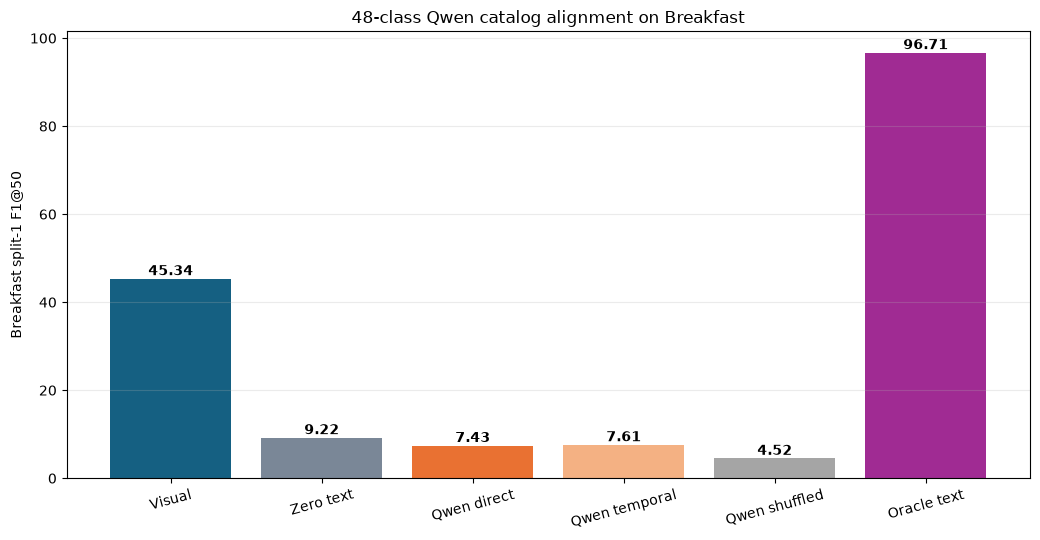

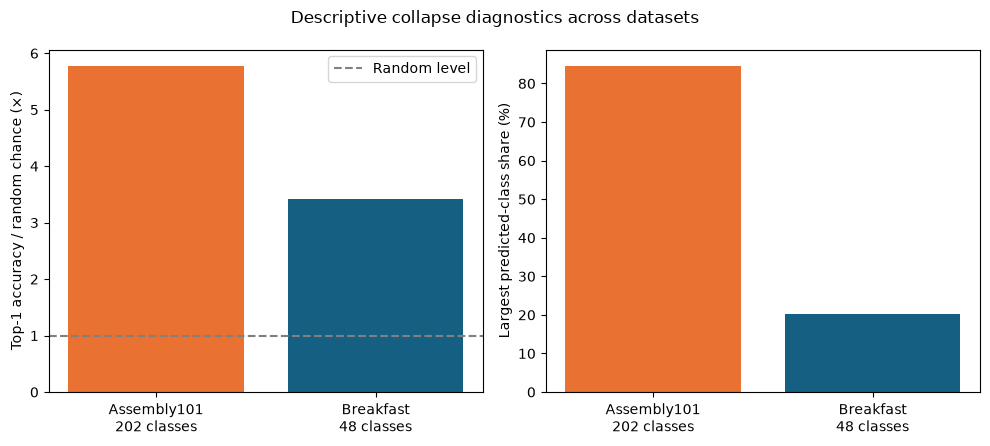

{
  "quick_check_positive": false,
  "visual_f1@50": 45.34,
  "qwen_direct_f1@50": 7.43,
  "qwen_temporal_f1@50": 7.61,
  "oracle_f1@50": 96.71,
  "top1_accuracy_percent": 7.118055555555555,
  "unique_top1_classes": 37,
  "largest_class_share_percent": 20.1140873015873,
  "next_step": "Report the 48-class result to Federico; do not tune on these labels before reporting."
}


In [28]:
metric_lookup = metrics_df.set_index("variant_key")

visual_f1 = float(metric_lookup.loc["controlled_visual_student", "f1@50"])
zero_f1 = float(metric_lookup.loc["teacher_zero_text", "f1@50"])
direct_f1 = float(metric_lookup.loc["teacher_qwen_top1", "f1@50"])
temporal_f1 = float(metric_lookup.loc["teacher_qwen_temporal", "f1@50"])
shuffled_f1 = float(metric_lookup.loc["teacher_qwen_shuffled", "f1@50"])
oracle_f1 = float(metric_lookup.loc["teacher_oracle_gt_text", "f1@50"])

decision = {
    "primary_metric": "Breakfast split-1 exploratory F1@50",
    "primary_variant": PRIMARY_VARIANT,
    "visual_f1@50": visual_f1,
    "zero_text_f1@50": zero_f1,
    "qwen_direct_f1@50": direct_f1,
    "qwen_temporal_f1@50": temporal_f1,
    "qwen_shuffled_f1@50": shuffled_f1,
    "oracle_f1@50": oracle_f1,
    "direct_delta_vs_visual": round(direct_f1 - visual_f1, 3),
    "direct_delta_vs_zero_text": round(direct_f1 - zero_f1, 3),
    "temporal_delta_vs_visual": round(temporal_f1 - visual_f1, 3),
    "minimum_required_visual_gain": MIN_REQUIRED_F1_50_GAIN,
    "direct_beats_visual": bool(direct_f1 - visual_f1 >= MIN_REQUIRED_F1_50_GAIN),
    "direct_beats_zero_text": bool(direct_f1 > zero_f1),
    "temporal_beats_direct": bool(temporal_f1 > direct_f1),
    "pseudo_accuracy_above_random": bool(
        diagnostic_summary["top1_accuracy_percent"] > diagnostic_summary["random_chance_percent"]
    ),
    "breakfast_accuracy_over_random_x": diagnostic_summary["accuracy_over_random_x"],
    "assembly101_accuracy_over_random_x": float(
        ASSEMBLY101_REFERENCE["top1_accuracy_percent"] / (100.0 / ASSEMBLY101_REFERENCE["catalog_classes"])
    ),
    "breakfast_predicted_target_class_coverage_percent": diagnostic_summary[
        "predicted_target_class_coverage_percent"
    ],
    "assembly101_predicted_target_class_coverage_percent": float(
        100.0 * ASSEMBLY101_REFERENCE["unique_top1_classes"]
        / ASSEMBLY101_REFERENCE["unique_target_classes"]
    ),
    "less_dominant_than_assembly101": bool(
        diagnostic_summary["largest_top1_class_share_percent"]
        < ASSEMBLY101_REFERENCE["largest_top1_class_share_percent"]
    ),
    "exploratory_only": True,
    "same_test_split_used_for_checkpoint_selection": True,
}
decision["catalog_alignment_improved_vs_assembly101"] = bool(
    decision["breakfast_accuracy_over_random_x"] > decision["assembly101_accuracy_over_random_x"]
    and decision["breakfast_predicted_target_class_coverage_percent"]
    > decision["assembly101_predicted_target_class_coverage_percent"]
    and decision["less_dominant_than_assembly101"]
)
decision["quick_check_positive"] = bool(
    decision["direct_beats_visual"]
    and decision["direct_beats_zero_text"]
    and decision["pseudo_accuracy_above_random"]
)

metrics_df.to_csv(LOCAL_OUT_ROOT / "breakfast_teacher_pseudotext_ablation.csv", index=False)
save_json_local(LOCAL_OUT_ROOT / "breakfast_exploratory_decision.json", decision)

plot_order = [
    "controlled_visual_student",
    "teacher_zero_text",
    "teacher_qwen_top1",
    "teacher_qwen_temporal",
    "teacher_qwen_shuffled",
    "teacher_oracle_gt_text",
]
plot_labels = ["Visual", "Zero text", "Qwen direct", "Qwen temporal", "Qwen shuffled", "Oracle text"]
plot_values = [float(metric_lookup.loc[key, "f1@50"]) for key in plot_order]
colors = ["#156082", "#7A8797", "#E97132", "#F4B183", "#A5A5A5", "#A02B93"]

fig, axis = plt.subplots(figsize=(10.5, 5.5))
bars = axis.bar(plot_labels, plot_values, color=colors)
axis.set_ylabel("Breakfast split-1 F1@50")
axis.set_title("48-class Qwen catalog alignment on Breakfast")
axis.grid(axis="y", alpha=0.25)
axis.tick_params(axis="x", rotation=15)
for bar, value in zip(bars, plot_values):
    axis.text(bar.get_x() + bar.get_width() / 2, value + 0.8, f"{value:.2f}", ha="center", fontweight="bold")
fig.tight_layout()
f1_chart = LOCAL_ARTIFACT_DIR / "breakfast_qwen_f1_at_50.png"
fig.savefig(f1_chart, dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(
    ["Assembly101\n202 classes", "Breakfast\n48 classes"],
    [decision["assembly101_accuracy_over_random_x"], decision["breakfast_accuracy_over_random_x"]],
    color=["#E97132", "#156082"],
)
axes[0].axhline(1.0, color="gray", linestyle="--", label="Random level")
axes[0].set_ylabel("Top-1 accuracy / random chance (×)")
axes[0].legend()
axes[1].bar(
    ["Assembly101\n202 classes", "Breakfast\n48 classes"],
    [ASSEMBLY101_REFERENCE["largest_top1_class_share_percent"], diagnostic_summary["largest_top1_class_share_percent"]],
    color=["#E97132", "#156082"],
)
axes[1].set_ylabel("Largest predicted-class share (%)")
fig.suptitle("Descriptive collapse diagnostics across datasets")
fig.tight_layout()
collapse_chart = LOCAL_ARTIFACT_DIR / "assembly101_vs_breakfast_qwen_collapse.png"
fig.savefig(collapse_chart, dpi=180, bbox_inches="tight")
plt.show()

final_summary = {
    "status": "completed",
    "experiment": "Breakfast Qwen3.5-2B full 48-class catalog alignment",
    "dataset": "Breakfast",
    "official_split": 1,
    "evaluation_subset": "test",
    "num_videos": len(test_ids),
    "catalog_classes": EXPECTED_NUM_CLASSES,
    "model_id": QWEN_MODEL_ID,
    "primary_metric": "F1@50",
    "generation": generation_summary,
    "pseudo_label_diagnostics": diagnostic_summary,
    "metrics": metrics_df.to_dict(orient="records"),
    "decision": decision,
    "assembly101_reference": ASSEMBLY101_REFERENCE,
    "methodological_note": (
        "Exploratory quick check. The frozen Breakfast visual and teacher checkpoints were selected "
        "using the same official split-1 test set in notebook 11, so this is not an unbiased held-out estimate."
    ),
    "next_step": "Report the 48-class result to Federico; do not tune on these labels before reporting.",
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
save_json_local(LOCAL_OUT_ROOT / "final_summary.json", final_summary)

for local_path in [
    LOCAL_OUT_ROOT / "breakfast_qwen_pseudo_label_diagnostics.csv",
    LOCAL_OUT_ROOT / "breakfast_qwen_diagnostic_summary.json",
    LOCAL_OUT_ROOT / "breakfast_teacher_pseudotext_ablation.csv",
    LOCAL_OUT_ROOT / "breakfast_exploratory_decision.json",
    LOCAL_OUT_ROOT / "final_summary.json",
    f1_chart,
    collapse_chart,
]:
    destination_root = DRIVE_ARTIFACT_DIR if local_path.parent == LOCAL_ARTIFACT_DIR else DRIVE_OUT_ROOT
    copy_with_retry(local_path, destination_root / local_path.name)

print(json.dumps({
    "quick_check_positive": decision["quick_check_positive"],
    "visual_f1@50": visual_f1,
    "qwen_direct_f1@50": direct_f1,
    "qwen_temporal_f1@50": temporal_f1,
    "oracle_f1@50": oracle_f1,
    "top1_accuracy_percent": diagnostic_summary["top1_accuracy_percent"],
    "unique_top1_classes": diagnostic_summary["unique_top1_classes"],
    "largest_class_share_percent": diagnostic_summary["largest_top1_class_share_percent"],
    "next_step": final_summary["next_step"],
}, indent=2))

del visual_model, teacher_model
gc.collect()
torch.cuda.empty_cache()

## Interpretation and reporting

Use the final printed summary and `final_summary.json`.

- If Qwen top-1 accuracy increases and the dominant-class share falls, the
  smaller catalog reduces collapse.
- If teacher + Qwen also beats both the visual student and zero-text teacher,
  the generated pseudo-text is useful on Breakfast.
- If collapse remains or F1@50 does not improve, the Assembly101 failure cannot
  be explained only by the 202-class catalog.
- Do not compare raw Assembly101 and Breakfast F1@50 values as if the datasets
  had equal difficulty. The cross-dataset plot is descriptive.
- Report the same-split checkpoint-selection limitation explicitly.

The notebook has no smoke/full switch. Select a T4 GPU and choose
**Runtime → Run all** once. If Colab itself terminates the runtime, rerunning
all cells will validate and skip already checkpointed videos.